# Scientific Track: ANNNI Phase Diagram Under Noise

Welcome to the Bitcamp 2026 theory challenge.

Your task: use PennyLane to **map the phase diagram** of the 1D Axial Next-Nearest-Neighbor
Ising (ANNNI) model in the $(\kappa, h)$ plane, then study how **depolarizing gate noise**
distorts the phase boundaries.

This notebook walks through the core tools from the starter kit and gets you to a working
clean-phase diagram so you can focus your hackathon time on the noise analysis and
physical interpretation.

Sections:
1. **The ANNNI model** — Hamiltonian, coupling structure, and the three competing forces
2. **Reading phase identity from observables** — what exact diagonalization tells us at four representative points
3. **Clean phase survey** — a full $(\kappa, h)$ grid with analytical boundaries overlaid
4. **The noise model** — depolarizing channels and what they do to order parameters
5. **Your phase diagrams** — workspace to build the noisy scans for submission

Read the `README.md` handout alongside this notebook for the full problem statement and
judging rubric.

In [3]:
# %pip install pennylane

In [4]:
import pennylane as qml

In [5]:
from pathlib import Path

print("QSite:", Path.cwd())
print("starter_kit:", (Path.cwd() / "starter_kit").exists())
print("__init__.py:", (Path.cwd() / "starter_kit" / "__init__.py").exists())

QSite: /Users/soardr/QSITE-2026-QuantumCoalition/Scientific Track
starter_kit: True
__init__.py: True


In [6]:
import numpy as np
import scipy
import h5py

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("h5py:", h5py.__version__)
print("PennyLane:", qml.__version__)

NumPy: 2.5.3
SciPy: 1.18.1
h5py: 3.16.0
PennyLane: 0.44.1


In [7]:
import starter_kit

print(starter_kit)

<module 'starter_kit' from '/Users/soardr/QSITE-2026-QuantumCoalition/Scientific Track/starter_kit/__init__.py'>


In [8]:
from pathlib import Path

kit = Path.cwd() / "starter_kit"

functions = [
    "animate_linecut",
    "build_annni_hamiltonian",
    "bkt_transition",
    "exact_ground_state",
    "ising_transition",
    "kt_transition",
    "noisy_entangling_layer",
    "order_parameter_summary",
    "plot_coupling_graph",
    "plot_observable_heatmap",
    "simple_noisy_energy",
]

for name in functions:
    found = []
    for f in kit.glob("*.py"):
        text = f.read_text(encoding="utf-8")
        if f"def {name}" in text:
            found.append(f.name)
    print(f"{name}: {found}")

animate_linecut: ['plotting.py']
build_annni_hamiltonian: ['annni.py']
bkt_transition: ['reference.py']
exact_ground_state: ['exact_diag.py']
ising_transition: ['reference.py']
kt_transition: ['reference.py']
noisy_entangling_layer: ['noise_utils.py']
order_parameter_summary: ['observables.py']
plot_coupling_graph: ['plotting.py']
plot_observable_heatmap: ['plotting.py']
simple_noisy_energy: ['noise_utils.py']


In [9]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from IPython.display import HTML, display

from starter_kit import (
    animate_linecut,
    #build_anh_hamiltonian,
    bkt_transition,
    exact_ground_state,
    ising_transition,
    kt_transition,
    noisy_entangling_layer,
    order_parameter_summary,
    plot_coupling_graph,
    plot_observable_heatmap,
    simple_noisy_energy,
)


#DEMO_N = 6

# Submission baseline
N_MAIN = 8

# Larger clean-system validation
N_CHECK = 12

NOISE_LEVELS = [0.0, 0.01, 0.05]

GRID_RES = 15

KAPPAS = np.linspace(0.0, 1.0, GRID_RES)
HS = np.linspace(0.0, 2.0, GRID_RES)

print(f"Main system size: N={N_MAIN}")
print(f"Clean validation size: N={N_CHECK}")
print(f"Grid: {GRID_RES} x {GRID_RES}")
print(f"PennyLane version: {qml.__version__}")
print(f"NumPy version: {np.__version__}")

# All worked examples use N=6 for speed.
# Your submission should target N≥8
DEMO_N = 12



Main system size: N=8
Clean validation size: N=12
Grid: 15 x 15
PennyLane version: 0.44.1
NumPy version: 2.5.3


## 1. The ANNNI Model

The 1D ANNNI Hamiltonian has three terms that **compete** against each other:

$$H = -J_1 \sum_i Z_i Z_{i+1} \;+\; J_1 \kappa \sum_i Z_i Z_{i+2} \;-\; h \sum_i X_i$$

| Term | Force | Wins when… |
|---|---|---|
| $-Z_i Z_{i+1}$ | Nearest-neighbor spins want to **align** (ferromagnetic) | $\kappa$ small, $h$ small |
| $+\kappa Z_i Z_{i+2}$ | Next-nearest spins want to **anti-align** (frustration) | $\kappa > 0.5$, $h$ small |
| $-h X_i$ | External field tries to **rotate** all spins out of the $Z$ basis | $h$ large |

Two dimensionless ratios parametrize the model: **$\kappa = |J_2|/J_1$** (frustration
strength, swept 0→1) and **$h/J_1$** (field strength, swept 0→2).  We set $J_1 = 1$.

The starter kit uses periodic boundary conditions and the $Z/Z/X$ convention throughout.
The PennyLane ANNNI demo uses an open-chain $X/X/Z$ convention — the physics is the same
but the analytical boundary formulas can look slightly different at finite $N$.

In [10]:
import pennylane as qml
from pennylane import numpy as np

def build_annni_hamiltonian(n_qubits, kappa, h, j1=1.0, periodic=True):
    coeffs = []
    obs = []

    # Nearest-neighbor ZZ (ferromagnetic)
    for i in range(n_qubits - 1 + int(periodic)):
        coeffs.append(-j1)
        obs.append(qml.Z(i % n_qubits) @ qml.Z((i+1) % n_qubits))

    # Next-nearest-neighbor ZZ (frustrating)
    for i in range(n_qubits - 2 + 2*int(periodic)):
        coeffs.append(j1 * kappa)  # positive: penalizes aligned next-nearest pairs (antiferromagnetic at this distance)
        obs.append(qml.Z(i % n_qubits) @ qml.Z((i+2) % n_qubits))

    # Transverse field X
    for i in range(n_qubits):
        coeffs.append(-h)
        obs.append(qml.X(i))

    return qml.dot(coeffs, obs)

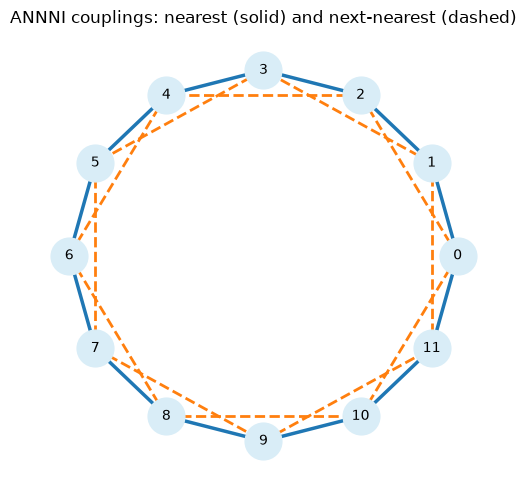

ANNNI Hamiltonian at kappa=0.3, h=0.5, N=12:
  Number of terms: 36

First few terms (coefficient × operator):
  -1.00 × Z(0) @ Z(1)
  -1.00 × Z(1) @ Z(2)
  -1.00 × Z(2) @ Z(3)
  -1.00 × Z(3) @ Z(4)
  -1.00 × Z(4) @ Z(5)
  -1.00 × Z(5) @ Z(6)
  ...


In [11]:
# Draw the coupling graph: solid = nearest-neighbor, dashed = next-nearest-neighbor (frustration)
fig, ax = plot_coupling_graph(n_qubits=12, periodic=True)
plt.tight_layout()
plt.show()

# Build the Hamiltonian at a sample point and inspect it
# qml.dot returns a Sum of SProd terms; each SProd has .scalar (coefficient) and .base (operator)
H_sample = build_annni_hamiltonian(n_qubits=DEMO_N, kappa=0.3, h=0.5)
print(f"ANNNI Hamiltonian at kappa=0.3, h=0.5, N={DEMO_N}:")
print(f"  Number of terms: {len(H_sample.operands)}")
print()
print("First few terms (coefficient × operator):")
for term in list(H_sample.operands)[:6]:
    print(f"  {float(term.scalar):+.2f} × {term.base}")
print("  ...")

In [12]:
def _basis_z_values(n_qubits):
    """Return z_i = +/-1 for every computational-basis state."""
    n = int(n_qubits)
    dim = 2 ** n
    basis = np.arange(dim, dtype=np.int64)

    z = np.empty((n, dim), dtype=np.float64)

    for i in range(n):
        bits = (basis >> i) & 1
        z[i] = 1.0 - 2.0 * bits

    return z


def build_sparse_annni_matrix(
    n_qubits,
    kappa,
    h,
    periodic=True,
):
    """
    Construct

        H = -sum_i Z_i Z_{i+1}
            + kappa sum_i Z_i Z_{i+2}
            - h sum_i X_i

    as a sparse real symmetric matrix.
    """
    n = int(n_qubits)
    dim = 2 ** n

    basis = np.arange(dim, dtype=np.int64)
    z = _basis_z_values(n)

    diagonal = np.zeros(dim, dtype=np.float64)

    # Nearest-neighbor interaction
    nn_count = n if periodic else n - 1

    for i in range(nn_count):
        j = (i + 1) % n
        diagonal += -z[i] * z[j]

    # Next-nearest-neighbor interaction
    nnn_count = n if periodic else n - 2

    for i in range(nnn_count):
        j = (i + 2) % n
        diagonal += float(kappa) * z[i] * z[j]

    rows = []
    cols = []
    data = []

    # Diagonal ZZ contribution
    rows.extend(basis.tolist())
    cols.extend(basis.tolist())
    data.extend(diagonal.tolist())

    # Transverse-field X flips one bit
    if h != 0.0:
        for i in range(n):
            flipped = basis ^ (1 << i)

            rows.extend(basis.tolist())
            cols.extend(flipped.tolist())
            data.extend(
                [-float(h)] * dim
            )

    return sp.csr_matrix(
        (data, (rows, cols)),
        shape=(dim, dim),
        dtype=np.float64,
    )

In [13]:
def exact_ground_state_extended(
    n_qubits,
    kappa,
    h,
    periodic=True,
):
    """
    Exact ground state and first excitation.

    For the sizes used here sparse Lanczos diagonalization is fast
    enough while avoiding a dense 2^N x 2^N matrix.
    """
    H = build_sparse_annni_matrix(
        n_qubits,
        kappa,
        h,
        periodic=periodic,
    )

    dim = H.shape[0]

    if dim <= 1024:
        dense = H.toarray()
        evals, evecs = scipy.linalg.eigh(
            dense,
            subset_by_index=[0, 1],
        )
    else:
        evals, evecs = eigsh(
            H,
            k=2,
            which="SA",
            tol=1e-10,
            maxiter=10000,
        )

        order = np.argsort(evals)
        evals = evals[order]
        evecs = evecs[:, order]

    state = np.asarray(
        evecs[:, 0],
        dtype=np.complex128,
    )

    state /= np.linalg.norm(state)

    return {
        "energy": float(evals[0]),
        "gap": float(max(evals[1] - evals[0], 0.0)),
        "state": state,
    }

In [14]:
def correlation_matrix_z(state, n_qubits):
    """
    C_ij = <Z_i Z_j>
    """
    n = int(n_qubits)
    z = _basis_z_values(n)

    probabilities = np.abs(state) ** 2

    weighted = z * probabilities[None, :]

    return weighted @ z.T


def structure_factor_from_correlations(correlation_matrix, q):
    """
    S(q) = (1/N) sum_{j,k}
           exp[i q(j-k)] <Z_j Z_k>
    """
    n = correlation_matrix.shape[0]
    positions = np.arange(n)

    phase = np.exp(
        1j * q *
        (
            positions[:, None]
            - positions[None, :]
        )
    )

    value = np.sum(
        phase * correlation_matrix
    ) / n

    return float(
        np.real_if_close(value)
    )


def x_magnetization(state, n_qubits):
    """
    M_x = (1/N) sum_i <X_i>
    """
    n = int(n_qubits)
    dim = 2 ** n
    basis = np.arange(dim, dtype=np.int64)

    values = []

    for i in range(n):
        flipped = basis ^ (1 << i)

        values.append(
            np.vdot(
                state,
                state[flipped],
            ).real
        )

    return float(np.mean(values))


def extract_physics_observables(
    state,
    n_qubits,
):
    """
    Main phase diagnostics.

    S(0)      -> ferromagnetic ordering
    S(pi/2)   -> period-4 antiphase ordering
    M_x       -> transverse-field / paramagnetic ordering
    q*        -> dominant ordering wavevector
    """
    n = int(n_qubits)

    C = correlation_matrix_z(
        state,
        n,
    )

    # Local correlation averages
    zz_nn = np.mean([
        C[i, (i + 1) % n]
        for i in range(n)
    ])

    zz_nnn = np.mean([
        C[i, (i + 2) % n]
        for i in range(n)
    ])

    mx = x_magnetization(
        state,
        n,
    )

    # Allowed momentum grid for the finite periodic chain.
    q_values = (
        2.0
        * np.pi
        * np.arange(n)
        / n
    )

    sq_values = np.array([
        structure_factor_from_correlations(
            C,
            float(q),
        )
        for q in q_values
    ])

    peak = int(
        np.argmax(sq_values)
    )

    q_peak = float(
        q_values[peak]
    )

    s0 = structure_factor_from_correlations(
        C,
        0.0,
    )

    spi2 = structure_factor_from_correlations(
        C,
        np.pi / 2,
    ) if n % 4 == 0 else np.nan

    return {
        "C": C,
        "zz_nn": float(zz_nn),
        "zz_nnn": float(zz_nnn),
        "mx": float(mx),
        "S0": float(s0 / n),
        "Spi2": float(spi2 / n) if np.isfinite(spi2) else np.nan,
        "q_values": q_values,
        "Sq_values": sq_values / n,
        "q_peak": q_peak,
        "Sq_peak": float(sq_values[peak] / n),
    }


def exact_point_extended(
    n_qubits,
    kappa,
    h,
):
    """One complete exact calculation."""
    gs = exact_ground_state_extended(
        n_qubits,
        kappa,
        h,
        periodic=True,
    )

    obs = extract_physics_observables(
        gs["state"],
        n_qubits,
    )

    return {
        **gs,
        **obs,
    }


 #4 phase classification

PHASE_CODES = {
    "FM": 0,
    "AP": 1,
    "PM": 2,
    "INCOMMENSURATE": 3,
}

PHASE_LABELS = {
    0: "FM",
    1: "AP",
    2: "PM",
    3: "Incommensurate",
}


def classify_phase(obs, kappa):
    """
    Conservative finite-size classifier.

    We use the dominant physical signature rather than a single
    arbitrary threshold.  The incommensurate class is deliberately
    labelled as a candidate finite-size signature, not proof of a
    thermodynamic floating phase.
    """
    s0 = float(obs["S0"])
    sap = float(obs["Spi2"]) if np.isfinite(obs["Spi2"]) else -np.inf
    mx = abs(float(obs["mx"]))

    q_peak = float(obs["q_peak"])
    q_peak_norm = q_peak / np.pi

    sq_peak = float(obs["Sq_peak"])

    # Large transverse polarization is the cleanest PM signal.
    # The threshold is intentionally modest because finite-N states
    # never reproduce the thermodynamic limiting values exactly.
    if mx > max(s0, sap, 0.20):
        return PHASE_CODES["PM"]

    # For kappa < 0.5, the expected ordered region is FM.
    if kappa < 0.5 and s0 >= max(sap, 0.15):
        return PHASE_CODES["FM"]

    # For kappa > 0.5, period-4 order is the antiphase signature.
    if kappa > 0.5 and sap >= max(s0, 0.15):
        return PHASE_CODES["AP"]

    # An allowed finite-size momentum that is neither 0 nor pi/2
    # is an incommensurate candidate.
    if (
        kappa > 0.5
        and sq_peak > 0.15
        and not np.isclose(q_peak_norm, 0.0)
        and not np.isclose(q_peak_norm, 0.5)
    ):
        return PHASE_CODES["INCOMMENSURATE"]

    # Otherwise fall back to whichever dominant signature is largest.
    if s0 >= sap and s0 >= mx:
        return PHASE_CODES["FM"]

    if sap >= s0 and sap >= mx:
        return PHASE_CODES["AP"]

    return PHASE_CODES["PM"]

In [15]:
import scipy.sparse as sp
import scipy
import scipy.linalg
import scipy.sparse
import scipy.sparse.linalg

In [16]:
FULL_RUN = False

RUN_GRID_RES = GRID_RES if FULL_RUN else 30

kappas_full = np.linspace(
    0.0,
    1.0,
    RUN_GRID_RES,
)

hs_full = np.linspace(
    0.0,
    2.0,
    RUN_GRID_RES,
)

clean_shape = (
    len(hs_full),
    len(kappas_full),
)

clean = {
    "energy": np.zeros(clean_shape),
    "gap": np.zeros(clean_shape),
    "zz_nn": np.zeros(clean_shape),
    "zz_nnn": np.zeros(clean_shape),
    "mx": np.zeros(clean_shape),
    "S0": np.zeros(clean_shape),
    "Spi2": np.zeros(clean_shape),
    "q_peak": np.zeros(clean_shape),
    "Sq_peak": np.zeros(clean_shape),
    "phase": np.zeros(
        clean_shape,
        dtype=int,
    ),
}

clean_states = np.zeros(
    (
        len(hs_full),
        len(kappas_full),
        2 ** N_MAIN,
    ),
    dtype=np.complex128,
)

print(
    f"Clean exact scan: "
    f"N={N_MAIN}, "
    f"{RUN_GRID_RES}x{RUN_GRID_RES}"
)

for col, kappa in enumerate(kappas_full):

    for row, h in enumerate(hs_full):

        result = exact_point_extended(
            N_MAIN,
            float(kappa),
            float(h),
        )

        clean["energy"][row, col] = result["energy"]
        clean["gap"][row, col] = result["gap"]
        clean["zz_nn"][row, col] = result["zz_nn"]
        clean["zz_nnn"][row, col] = result["zz_nnn"]
        clean["mx"][row, col] = result["mx"]
        clean["S0"][row, col] = result["S0"]
        clean["Spi2"][row, col] = result["Spi2"]
        clean["q_peak"][row, col] = result["q_peak"]
        clean["Sq_peak"][row, col] = result["Sq_peak"]

        clean["phase"][row, col] = classify_phase(
            result,
            float(kappa),
        )

        clean_states[row, col] = result["state"]

    print(
        f"  kappa column "
        f"{col + 1}/{len(kappas_full)} complete"
    )

print("Clean exact scan complete.")

Clean exact scan: N=8, 30x30
  kappa column 1/30 complete
  kappa column 2/30 complete
  kappa column 3/30 complete
  kappa column 4/30 complete
  kappa column 5/30 complete
  kappa column 6/30 complete
  kappa column 7/30 complete
  kappa column 8/30 complete
  kappa column 9/30 complete
  kappa column 10/30 complete
  kappa column 11/30 complete
  kappa column 12/30 complete
  kappa column 13/30 complete
  kappa column 14/30 complete
  kappa column 15/30 complete
  kappa column 16/30 complete
  kappa column 17/30 complete
  kappa column 18/30 complete
  kappa column 19/30 complete
  kappa column 20/30 complete
  kappa column 21/30 complete
  kappa column 22/30 complete
  kappa column 23/30 complete
  kappa column 24/30 complete
  kappa column 25/30 complete
  kappa column 26/30 complete
  kappa column 27/30 complete
  kappa column 28/30 complete
  kappa column 29/30 complete
  kappa column 30/30 complete
Clean exact scan complete.


In [17]:
def fidelity(state_a, state_b):
    return float(
        np.abs(
            np.vdot(
                state_a,
                state_b,
            )
        ) ** 2
    )


def fidelity_susceptibility(
    states,
    grid_spacing,
    axis,
):
    """
    chi_F ≈ -2 log(F) / delta^2
    """
    result = np.full(
        states.shape[:2],
        np.nan,
    )

    n_h, n_k = states.shape[:2]

    if axis == "h":

        for row in range(n_h - 1):
            for col in range(n_k):

                F = fidelity(
                    states[row, col],
                    states[row + 1, col],
                )

                F = np.clip(
                    F,
                    1e-15,
                    1.0,
                )

                result[row, col] = (
                    -2.0
                    * np.log(F)
                    / grid_spacing ** 2
                )

    elif axis == "kappa":

        for row in range(n_h):
            for col in range(n_k - 1):

                F = fidelity(
                    states[row, col],
                    states[row, col + 1],
                )

                F = np.clip(
                    F,
                    1e-15,
                    1.0,
                )

                result[row, col] = (
                    -2.0
                    * np.log(F)
                    / grid_spacing ** 2
                )

    else:
        raise ValueError(
            "axis must be 'h' or 'kappa'"
        )

    return result


dh = hs_full[1] - hs_full[0]
dk = kappas_full[1] - kappas_full[0]

clean["chi_h"] = fidelity_susceptibility(
    clean_states,
    dh,
    "h",
)

clean["chi_kappa"] = fidelity_susceptibility(
    clean_states,
    dk,
    "kappa",
)

In [18]:
k_ising = np.linspace(
    0.01,
    0.499,
    400,
)

k_high = np.linspace(
    0.501,
    1.0,
    400,
)

h_ising_ref = np.asarray(
    ising_transition(k_ising),
    dtype=float,
)

h_kt_ref = np.asarray(
    kt_transition(k_high),
    dtype=float,
)

h_bkt_ref = np.asarray(
    bkt_transition(k_high),
    dtype=float,
)


def overlay_reference_lines(ax):
    ax.plot(
        k_ising,
        h_ising_ref,
        "w--",
        lw=1.8,
        label="Ising reference",
    )

    ax.plot(
        k_high,
        h_kt_ref,
        "w:",
        lw=1.8,
        label="KT reference",
    )

    ax.plot(
        k_high,
        h_bkt_ref,
        "w-.",
        lw=1.8,
        label="BKT reference",
    )

    ax.axvline(
        0.5,
        color="white",
        linestyle="--",
        alpha=0.6,
        lw=1.0,
    )

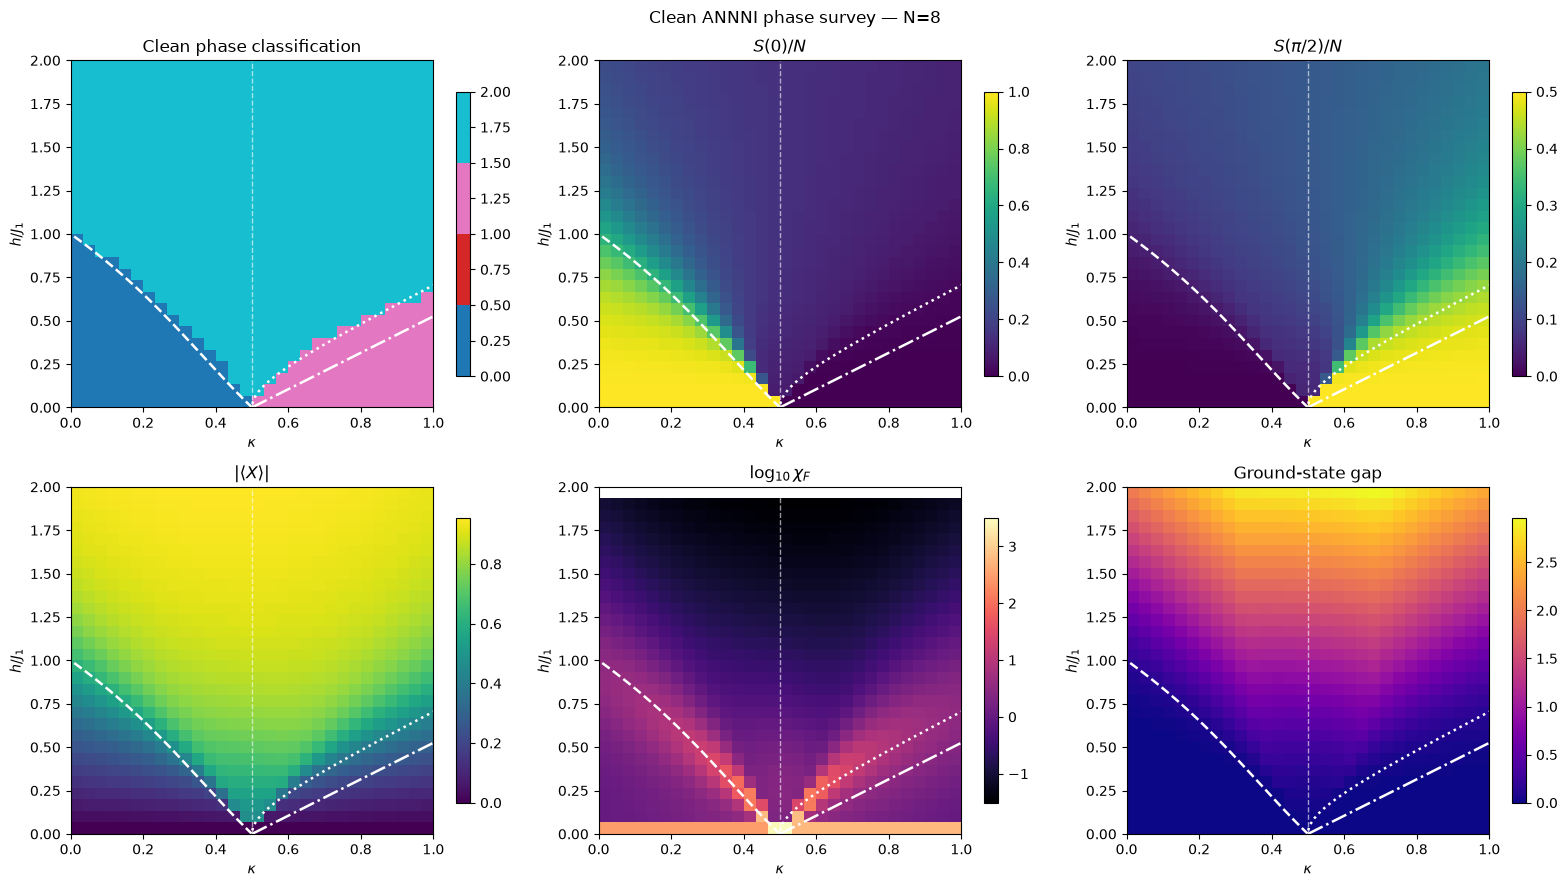

In [19]:
phase_cmap = plt.get_cmap(
    "tab10",
    4,
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 9),
)

panel_data = [
    (
        clean["phase"],
        "Clean phase classification",
        phase_cmap,
        0,
    ),
    (
        clean["S0"],
        r"$S(0)/N$",
        "viridis",
        None,
    ),
    (
        clean["Spi2"],
        r"$S(\pi/2)/N$",
        "viridis",
        None,
    ),
    (
        np.abs(clean["mx"]),
        r"$|\langle X\rangle|$",
        "viridis",
        None,
    ),
    (
        np.log10(
            np.maximum(
                clean["chi_h"],
                1e-12,
            )
        ),
        r"$\log_{10}\chi_F$",
        "magma",
        None,
    ),
    (
        clean["gap"],
        "Ground-state gap",
        "plasma",
        None,
    ),
]

for ax, (data, title, cmap, _) in zip(
    axes.ravel(),
    panel_data,
):

    im = ax.imshow(
        data,
        origin="lower",
        aspect="auto",
        extent=[
            kappas_full.min(),
            kappas_full.max(),
            hs_full.min(),
            hs_full.max(),
        ],
        cmap=cmap,
    )

    overlay_reference_lines(ax)

    ax.set_xlabel(
        r"$\kappa$"
    )

    ax.set_ylabel(
        r"$h/J_1$"
    )

    ax.set_title(title)

    fig.colorbar(
        im,
        ax=ax,
        shrink=0.82,
    )

fig.suptitle(
    f"Clean ANNNI phase survey — N={N_MAIN}"
)

fig.tight_layout()

fig.savefig(
    "phase_diagram_clean_p0.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    "phase_diagram_clean_p0.pdf",
    bbox_inches="tight",
)

plt.show()

In [20]:
from pennylane import numpy as qnp

VQE_LAYERS = 4
VQE_MAX_STEPS = 70
VQE_STEPSIZE = 0.04
SEED = 500


def apply_fixed_depth_ansatz(
    params,
    n_qubits,
    p=0.0,
    initialization="pm",
):
    """
    ANNNI-aware variational ansatz.

    initialization:
        "pm" -> |+>^N
        "fm" -> |000...0>
        "ap" -> |0011 0011...>

    The AP state is used as a physically informed reference
    state and is only weakly perturbed by the variational
    rotations.
    """

    # ========================================================
    # INITIAL STATE
    # ========================================================

    if initialization == "pm":

        for i in range(n_qubits):
            qml.Hadamard(wires=i)

    elif initialization == "fm":

        # |000...0>
        pass

    elif initialization == "ap":

        # |00110011...>
        #pattern = [0, 0, 1, 1]

        bits = np.array([0, 0, 1, 1]*(n_qubits // 4))

        for i, bit in  enumerate(bits):

                if bit == 1:
                   qml.PauliX(
                   wires=i
               )
            
           

        

    else:

        raise ValueError(
            f"Unknown initialization: {initialization}"
        )

    # ========================================================
    # VARIATIONAL LAYERS
    # ========================================================

    for layer in range(VQE_LAYERS):

        # ----------------------------------------------------
        # Single-qubit rotations
        # ----------------------------------------------------

        for i in range(n_qubits):

           # if initialization == "ap":

                # AP reference state:
                # use only small Y rotations initially
                qml.RY(
                    params[layer, i, 0],
                    wires=i,
                )

                qml.RZ(
                    params[layer, i, 1],
                    wires=i,
                )


                qml.RX(
                    
                    params[layer, i, 2],
                    wires=i,
                )

        # ----------------------------------------------------
        # Nearest-neighbor entangling layer
        # ----------------------------------------------------
    if initialization != "ap":
        for i in range(n_qubits):

            qml.CNOT(
                wires=[
                    i,
                    (i + 1) % n_qubits,
                ]
            )

            if p > 0.0:

                qml.DepolarizingChannel(
                    p,
                    wires=(i + 1) % n_qubits,
                )

        # ----------------------------------------------------
        # Next-nearest-neighbor entangling layer
        # ----------------------------------------------------

        for i in range(n_qubits):

            qml.CNOT(
                wires=[
                    i,
                    (i + 2) % n_qubits,
                ]
            )

            if p > 0.0:

                qml.DepolarizingChannel(
                    p,
                    wires=(i + 2) % n_qubits,
                )

def make_vqe_cost(n_qubits, layers):

    dev = qml.device(
        "default.qubit",
        wires=n_qubits,
    )

    @qml.qnode(
        dev,
        interface="autograd",
        diff_method="adjoint",
    )
    def cost(params, kappa, h, initialization="pm"):

        apply_fixed_depth_ansatz(
            params,
            n_qubits,
            p=0.0,
            initialization=initialization
        )

        # ANNNI Hamiltonian
        coefficients = []
        observables = []

        # - sum_i Z_i Z_{i+1}
        for i in range(n_qubits):
            coefficients.append(-1.0)
            observables.append(
                qml.PauliZ(i) @ qml.PauliZ((i + 1) % n_qubits)
            )

        # + kappa sum_i Z_i Z_{i+2}
        for i in range(n_qubits):
            coefficients.append(kappa)
            observables.append(
                qml.PauliZ(i) @ qml.PauliZ((i + 2) % n_qubits)
            )

        # - h sum_i X_i
        for i in range(n_qubits):
            coefficients.append(-h)
            observables.append(
                qml.PauliX(i)
            )

        H = qml.Hamiltonian(
            coefficients,
            observables,
        )

        return qml.expval(H)

    return cost


VQE_COST = make_vqe_cost(
    N_MAIN,
    VQE_LAYERS,
)


def optimize_vqe_point(
    kappa,
    h,
    initial_params=None,
    max_steps=80,
    stepsize=0.02,
    seed=SEED,
):
    """
    ANNNI-aware VQE.

    Uses physically motivated starting states:

        FM -> |000...0>
        AP -> |0011...>
        PM -> |++++...>

    The AP state is initialized exactly and optimized
    conservatively so that the optimizer does not destroy
    a good antiphase starting point.

    The best energy encountered during optimization is kept.
    """

    rng = np.random.default_rng(seed)

    candidates = []

    # ========================================================
    # FM
    # ========================================================

    params_fm = qml.numpy.array(
        0.01
        * rng.standard_normal(
            (
                VQE_LAYERS,
                N_MAIN,
                3,
            )
        ),
        requires_grad=True,
    )

    optimizer = qml.AdamOptimizer(
        stepsize=stepsize
    )

    best_params = params_fm
    best_energy = float(
        VQE_COST(
            params_fm,
            kappa,
            h,
            "fm",
        )
    )

    for step in range(max_steps):

        params_fm, energy = optimizer.step_and_cost(
            lambda x:
                VQE_COST(
                    x,
                    kappa,
                    h,
                    "fm",
                ),
            params_fm,
        )

        current = float(
            VQE_COST(
                params_fm,
                kappa,
                h,
                "fm",
            )
        )

        if current < best_energy:

            best_energy = current
            best_params = params_fm

    print(
        f"  fm initialization -> "
        f"E = {best_energy:+.6f}"
    )

    candidates.append(
        (
            best_energy,
            best_params,
            "fm",
        )
    )

    # ========================================================
    # AP
    # ========================================================

    # Exactly the classical antiphase state at initialization
    params_ap = qml.numpy.zeros(
        (
            VQE_LAYERS,
            N_MAIN,
            3,
        ),
        requires_grad=True,
    )

    optimizer = qml.AdamOptimizer(
        stepsize=stepsize
    )

    best_params = params_ap

    best_energy = float(
        VQE_COST(
            params_ap,
            kappa,
            h,
            "ap",
        )
    )

    for step in range(max_steps):

        params_ap, energy = optimizer.step_and_cost(
            lambda x:
                VQE_COST(
                    x,
                    kappa,
                    h,
                    "ap",
                ),
            params_ap,
        )

        current = float(
            VQE_COST(
                params_ap,
                kappa,
                h,
                "ap",
            )
        )

        # CRITICAL:
        # Keep the best state encountered.
        if current < best_energy:

            best_energy = current
            best_params = params_ap

    print(
        f"  ap initialization -> "
        f"E = {best_energy:+.6f}"
    )

    candidates.append(
        (
            best_energy,
            best_params,
            "ap",
        )
    )

    # ========================================================
    # PM
    # ========================================================

    params_pm = qml.numpy.array(
        0.01
        * rng.standard_normal(
            (
                VQE_LAYERS,
                N_MAIN,
                3,
            )
        ),
        requires_grad=True,
    )

    optimizer = qml.AdamOptimizer(
        stepsize=stepsize
    )

    best_params = params_pm

    best_energy = float(
        VQE_COST(
            params_pm,
            kappa,
            h,
            "pm",
        )
    )

    for step in range(max_steps):

        params_pm, energy = optimizer.step_and_cost(
            lambda x:
                VQE_COST(
                    x,
                    kappa,
                    h,
                    "pm",
                ),
            params_pm,
        )

        current = float(
            VQE_COST(
                params_pm,
                kappa,
                h,
                "pm",
            )
        )

        if current < best_energy:

            best_energy = current
            best_params = params_pm

    print(
        f"  pm initialization -> "
        f"E = {best_energy:+.6f}"
    )

    candidates.append(
        (
            best_energy,
            best_params,
            "pm",
        )
    )

    # ========================================================
    # Select best candidate
    # ========================================================

    best_energy, best_params, best_initialization = min(
        candidates,
        key=lambda item: item[0],
    )

    return (
        best_params,
        best_energy,
    )

In [21]:
exact = exact_point_extended(
    N_MAIN,
    0.20,
    0.20,
)

print(exact.keys())

dict_keys(['energy', 'gap', 'state', 'C', 'zz_nn', 'zz_nnn', 'mx', 'S0', 'Spi2', 'q_values', 'Sq_values', 'q_peak', 'Sq_peak'])


In [22]:
import time

In [23]:
VALIDATION_POINTS = [
    (0.20, 0.20),
    (0.80, 0.20),
    (0.20, 1.60),
    (0.80, 0.30),
]

print()
print("VQE validation")
print("=" * 72)

# ============================================================
# STORE VALIDATION RESULTS
# ============================================================

validation_results = []

for kappa, h in VALIDATION_POINTS:

    # --------------------------------------------------------
    # Exact diagonalization
    # --------------------------------------------------------

    time_classical_exact_method = time.time()
    exact = exact_point_extended(
        N_MAIN,
        kappa,
        h,
    )
    time_classical_exact_method = time.time() - time_classical_exact_method

    # --------------------------------------------------------
    # VQE

    time_quantum_method = time.time()
    params, vqe_energy = optimize_vqe_point(
        kappa,
        h,
        max_steps=120,
        seed=SEED,
    )
    time_quantum_method = time.time() - time_quantum_method

    error = abs(
        vqe_energy
        - exact["energy"]
    )

    # --------------------------------------------------------
    # Phase classification
    # --------------------------------------------------------

    phase = classify_phase(
        exact,
        kappa,
    )

    # Store everything

    validation_results.append(
        {
            "kappa": kappa,
            "h": h,
            "label": f"({kappa:.2f}, {h:.2f})",

            "exact_energy": exact["energy"],
            "vqe_energy": vqe_energy,
            "error": error,

            "gap": exact["gap"],

            "zz_nn": exact["zz_nn"],
            "zz_nnn": exact["zz_nnn"],

            "mx": exact["mx"],

            "S0": exact["S0"],
            "Spi2": exact["Spi2"],

            "phase": phase,
        }
    )

 

    print(
        f"(kappa,h)=({kappa:.2f},{h:.2f}) | "
        f"Exact={exact['energy']:+.6f} | "
        f"VQE={vqe_energy:+.6f} | "
        f"|error|={error:.3e}"
        f"time taken for classical calculation={time_classical_exact_method:.3e}"
        f"time taken for quantum method={time_quantum_method:.3e}"
    )



VQE validation
  fm initialization -> E = -6.400000
  ap initialization -> E = -2.000000
  pm initialization -> E = -1.600000
(kappa,h)=(0.20,0.20) | Exact=-6.500854 | VQE=-6.400000 | |error|=1.009e-01time taken for classical calculation=3.373e-02time taken for quantum method=5.255e+01
  fm initialization -> E = -6.399985
  ap initialization -> E = -6.500000
  pm initialization -> E = -1.600000
(kappa,h)=(0.80,0.20) | Exact=-6.502928 | VQE=-6.500000 | |error|=2.928e-03time taken for classical calculation=9.002e-03time taken for quantum method=4.337e+01
  fm initialization -> E = -6.400000
  ap initialization -> E = -12.800000


KeyboardInterrupt: 

## the same but using TensorCircuit-ng and JAX

In [24]:
import tensorcircuit as tc
import jax
import jax.numpy as jnp

import time

tc.set_backend("jax")

jax_backend

In [48]:
VQE_LAYERS = 4
VQE_MAX_STEPS = 120
VQE_STEPSIZE = 0.04
SEED = 500
TOP_K = 16

In [49]:
def apply_fixed_depth_ansatz_tc_pm(circuit: tc.MPSCircuit, params, n_qubits):
    n = int(n_qubits)
    layers = params.shape[0]

    for i in range(n):
        circuit.h(int(i))

    for layer in range(VQE_LAYERS):
        for i in range(n):
            circuit.ry(i, theta=params[layer, i, 0])
            circuit.rz(i, theta=params[layer, i, 1])
            circuit.rx(i, theta=params[layer, i, 2])

    # NN CNOT ring (explicit int casting for qubit indices)
    for i in range(n):
        control = int(i)
        target = int((i + 1) % n)
        circuit.cnot(control, target)

    # NNN CNOT ring (explicit int casting for qubit indices)
    for i in range(n):
        control = i
        target = int((i + 2) % n)
        circuit.cnot(control, target)

    return circuit

In [50]:
def apply_fixed_depth_ansatz_tc_fm(circuit: tc.MPSCircuit, params, n_qubits):
    n = int(n_qubits)
    layers = params.shape[0]

    # for i in range(n):
    #     circuit.h(int(i))

    for layer in range(VQE_LAYERS):
        for i in range(n):
            circuit.ry(i, theta=params[layer, i, 0])
            circuit.rz(i, theta=params[layer, i, 1])
            circuit.rx(i, theta=params[layer, i, 2])

    # NN CNOT ring (explicit int casting for qubit indices)
    for i in range(n):
        control = int(i)
        target = int((i + 1) % n)
        circuit.cnot(control, target)

    # NNN CNOT ring (explicit int casting for qubit indices)
    for i in range(n):
        control = i
        target = int((i + 2) % n)
        circuit.cnot(control, target)

    return circuit

In [51]:
def apply_fixed_depth_ansatz_tc_ap(circuit: tc.MPSCircuit, params, n_qubits):
    n = int(n_qubits)
    layers = params.shape[0]

    ap_indices = [i for i in range(n) if (i % 4) in (2, 3)]
    for idx in ap_indices:
        circuit.x(int(idx))

    for layer in range(VQE_LAYERS):
        for i in range(n):
            circuit.ry(i, theta=params[layer, i, 0])
            circuit.rz(i, theta=params[layer, i, 1])
            circuit.rx(i, theta=params[layer, i, 2])

    return circuit

In [52]:
def make_vqe_cost_tc(n_qubits, layers, phase):
    n = int(n_qubits)

    def cost(params, kappa, h):
        circ = tc.MPSCircuit(n, split={"max_singular_values": TOP_K})

        if phase == "pm":
            circ = apply_fixed_depth_ansatz_tc_pm(circ, params, n_qubits)
        elif phase == "ap":
            circ = apply_fixed_depth_ansatz_tc_ap(circ, params, n_qubits)
        elif phase == "fm":
            circ = apply_fixed_depth_ansatz_tc_fm(circ, params, n_qubits)

        energy = 0.0
        for i in range(n):
            energy += -1.0 * circ.expectation_ps(z=[i, (i + 1) % n])
        for i in range(n):
            energy += kappa * circ.expectation_ps(z=[i, (i + 2) % n])
        for i in range(n):
            energy += -h * circ.expectation_ps(x=[i])

        return jnp.real(energy)

    return cost

In [53]:
VQE_COS_pm = make_vqe_cost_tc(
    N_MAIN,
    VQE_LAYERS,
    "pm"
)

VQE_COS_ap = make_vqe_cost_tc(
    N_MAIN,
    VQE_LAYERS,
    "ap"
)

VQE_COS_fm = make_vqe_cost_tc(
    N_MAIN,
    VQE_LAYERS,
    "fm"
)

In [54]:
import optax

In [55]:
# def run_phase_optimization(
#     init_params,
#     kappa,
#     h,
#     vqe_cost_fn,
#     max_steps=80,
#     stepsize=0.02,
# ):
#     """
#     Helper to optimize a single initialization phase using JAX + Optax.
#     Tracks and returns the best energy and corresponding parameter set.
#     """
#     params = jnp.array(init_params)

#     # Initialize Optax Adam optimizer
#     # optimizer = optax.adam(learning_rate=stepsize)
#     optimizer = optax.optimistic_gradient_descent(learning_rate=stepsize)

#     opt_state = optimizer.init(params)

#     # Define JIT-compiled optimization update step
#     @jax.jit
#     def update_step(p, state):
#         # Pass phase string into the JAX cost function
#         val, grads = jax.value_and_grad(vqe_cost_fn)(p, kappa, h)
#         updates, state = optimizer.update(grads, state, p)
#         p = optax.apply_updates(p, updates)
#         return p, state, val

#     # Evaluate initial energy
#     initial_energy = float(vqe_cost_fn(params, kappa, h))
#     best_energy = initial_energy
#     best_params = params

#     for _ in range(max_steps):
#         params, opt_state, energy = update_step(params, opt_state)
#         current_energy = float(energy)

#         # Track and keep the best energy encountered
#         if current_energy < best_energy:
#             best_energy = current_energy
#             best_params = params

#     return best_energy, best_params

def create_fast_phase_runner(vqe_cost_fn, stepsize=0.02, max_steps=80):
    optimizer = optax.adam(learning_rate=stepsize)

    def _step(carry, _):
        params, opt_state, best_params, best_energy, kappa, h = carry
        energy, grads = jax.value_and_grad(vqe_cost_fn)(params, kappa, h)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        params = optax.apply_updates(params, updates)

        is_better = energy < best_energy
        best_energy = jnp.where(is_better, energy, best_energy)
        best_params = jnp.where(is_better, params, best_params)

        return (params, opt_state, best_params, best_energy, kappa, h), energy

    # @jax.jit MUST be compiled here once and reused
    @jax.jit
    def run_optimization(init_params, kappa, h):
        params = jnp.array(init_params)
        opt_state = optimizer.init(params)
        initial_energy = vqe_cost_fn(params, kappa, h)

        init_carry = (params, opt_state, params, initial_energy, kappa, h)
        final_carry, _ = jax.lax.scan(_step, init_carry, None, length=max_steps)
        
        _, _, best_params, best_energy, _, _ = final_carry
        return best_energy, best_params

    return run_optimization

In [56]:
print("Pre-compiling JAX runners for FM, AP, and PM...")

RUNNERS = {
    phase: create_fast_phase_runner(
        make_vqe_cost_tc(N_MAIN, VQE_LAYERS, phase),
        stepsize=VQE_STEPSIZE,
        max_steps=VQE_MAX_STEPS,
    )
    for phase in ["fm", "ap", "pm"]
}

Pre-compiling JAX runners for FM, AP, and PM...


In [57]:
# def optimize_vqe_point(
#     kappa,
#     h,
#     initial_params=None,
#     max_steps=80,
#     stepsize=0.02,
#     seed=SEED,
# ):
#     """
#     ANNNI-aware VQE optimized with JAX and Optax.

#     Uses physically motivated starting states:
#         FM -> |000...0>
#         AP -> |0011...>
#         PM -> |++++...>
#     """
#     rng = np.random.default_rng(seed)
#     candidates = []

#     # ========================================================
#     # 1. FM (Ferromagnetic) Initialization
#     # ========================================================
#     # Get cost function instance
#     vqe_cost = make_vqe_cost_tc(N_MAIN, VQE_LAYERS, "fm")

#     params_fm_init = 0.01 * rng.standard_normal((VQE_LAYERS, N_MAIN, 3))

#     time_quantum_fm = time.time()
#     best_energy_fm, best_params_fm = run_phase_optimization(
#         params_fm_init,
#         kappa,
#         h,
#         vqe_cost,
#         max_steps=max_steps,
#         stepsize=stepsize,
#     )
#     print("time taken for quantum FM:", time.time() - time_quantum_fm)

#     print(f"  fm initialization -> E = {best_energy_fm:+.6f}")
#     candidates.append((best_energy_fm, best_params_fm, "fm"))

#     # ========================================================
#     # 2. AP (Antiphase) Initialization
#     # ========================================================
#     # Get cost function instance
#     vqe_cost = make_vqe_cost_tc(N_MAIN, VQE_LAYERS, "ap")
    
#     # Exactly the classical antiphase state at initialization
#     params_ap_init = np.zeros((VQE_LAYERS, N_MAIN, 3))

#     time_quantum_ap = time.time()
#     best_energy_ap, best_params_ap = run_phase_optimization(
#         params_ap_init,
#         kappa,
#         h,
#         vqe_cost,
#         max_steps=max_steps,
#         stepsize=stepsize,
#     )
#     print("time taken for quantum AP:", time.time() - time_quantum_ap)

#     print(f"  ap initialization -> E = {best_energy_ap:+.6f}")
#     candidates.append((best_energy_ap, best_params_ap, "ap"))

#     # ========================================================
#     # 3. PM (Paramagnetic) Initialization
#     # ========================================================
#     # Get cost function instance
#     vqe_cost = make_vqe_cost_tc(N_MAIN, VQE_LAYERS, "pm")
    
#     params_pm_init = 0.01 * rng.standard_normal((VQE_LAYERS, N_MAIN, 3))

#     time_quantum_pm = time.time()
#     best_energy_pm, best_params_pm = run_phase_optimization(
#         params_pm_init,
#         kappa,
#         h,
#         vqe_cost,
#         max_steps=max_steps,
#         stepsize=stepsize,
#     )
#     print("time taken for quantum PM:", time.time() - time_quantum_pm)

#     print(f"  pm initialization -> E = {best_energy_pm:+.6f}")
#     candidates.append((best_energy_pm, best_params_pm, "pm"))

#     # ========================================================
#     # Select best candidate across all physical phases
#     # ========================================================
#     best_energy, best_params, best_initialization = min(
#         candidates,
#         key=lambda item: item[0],
#     )

#     return np.asarray(best_params), best_energy

def optimize_vqe_point(
    kappa,
    h,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    candidates = []

    for phase in ["fm", "ap", "pm"]:
        runner = RUNNERS[phase]

        if phase == "ap":
            init_params = np.zeros((VQE_LAYERS, N_MAIN, 3))
        else:
            init_params = 0.01 * rng.standard_normal((VQE_LAYERS, N_MAIN, 3))

        t0 = time.time()
        
        # Uses the pre-compiled global JAX function
        best_energy_jax, best_params_jax = runner(init_params, kappa, h)
        
        best_energy = float(best_energy_jax)
        best_params = np.asarray(best_params_jax)
        
        print(f"  time {phase.upper()}: {time.time() - t0:.4f}s | E = {best_energy:+.6f}")
        candidates.append((best_energy, best_params, phase))

    best_energy, best_params, _ = min(candidates, key=lambda item: item[0])
    return best_params, best_energy

In [60]:
VALIDATION_POINTS = [
    (0.20, 0.20),
    (0.80, 0.20),
    (0.20, 1.60),
    (0.80, 0.30),
]

print()
print("VQE validation")
print("=" * 72)

# ============================================================
# STORE VALIDATION RESULTS
# ============================================================

validation_results = []

for kappa, h in VALIDATION_POINTS:

    # --------------------------------------------------------
    # Exact diagonalization
    # --------------------------------------------------------

    time_classical_exact_method = time.time()
    exact = exact_point_extended(
        N_MAIN,
        kappa,
        h,
    )
    time_classical_exact_method = time.time() - time_classical_exact_method

    # --------------------------------------------------------
    # VQE

    time_quantum_method = time.time()
    params, vqe_energy = optimize_vqe_point(
        kappa,
        h,
        # max_steps=VQE_MAX_STEPS,
        seed=SEED,
    )
    time_quantum_method = time.time() - time_quantum_method

    error = abs(
        vqe_energy
        - exact["energy"]
    )

    # --------------------------------------------------------
    # Phase classification
    # --------------------------------------------------------

    phase = classify_phase(
        exact,
        kappa,
    )

    # Store everything

    validation_results.append(
        {
            "kappa": kappa,
            "h": h,
            "label": f"({kappa:.2f}, {h:.2f})",

            "exact_energy": exact["energy"],
            "vqe_energy": vqe_energy,
            "error": error,

            "gap": exact["gap"],

            "zz_nn": exact["zz_nn"],
            "zz_nnn": exact["zz_nnn"],

            "mx": exact["mx"],

            "S0": exact["S0"],
            "Spi2": exact["Spi2"],

            "phase": phase,
        }
    )

 

    print(
        f"(kappa,h)=({kappa:.2f},{h:.2f}) | "
        f"Exact={exact['energy']:+.6f} | "
        f"VQE={vqe_energy:+.6f} | "
        f"|error|={error:.3e}"
        f"time taken for classical calculation={time_classical_exact_method:.3e}"
        f"time taken for quantum method={time_quantum_method:.3e}"
    )



VQE validation
  time FM: 2.4500s | E = -6.400011
  time AP: 0.3308s | E = -2.000003
  time PM: 1.3479s | E = -1.599999
(kappa,h)=(0.20,0.20) | Exact=-6.500854 | VQE=-6.400011 | |error|=1.008e-01time taken for classical calculation=1.249e-01time taken for quantum method=4.141e+00
  time FM: 0.8575s | E = -6.400010
  time AP: 0.1206s | E = -6.500020
  time PM: 1.8704s | E = -1.599996
(kappa,h)=(0.80,0.20) | Exact=-6.502928 | VQE=-6.500020 | |error|=2.909e-03time taken for classical calculation=1.584e-02time taken for quantum method=2.852e+00
  time FM: 1.7547s | E = -6.400017
  time AP: 0.2144s | E = -12.800014
  time PM: 1.3996s | E = -12.799977
(kappa,h)=(0.20,1.60) | Exact=-13.916265 | VQE=-12.800014 | |error|=1.116e+00time taken for classical calculation=2.422e-02time taken for quantum method=3.375e+00
  time FM: 0.9576s | E = -6.400005
  time AP: 0.1172s | E = -6.625020
  time PM: 1.7564s | E = -2.399979
(kappa,h)=(0.80,0.30) | Exact=-6.640454 | VQE=-6.625020 | |error|=1.543e-02ti

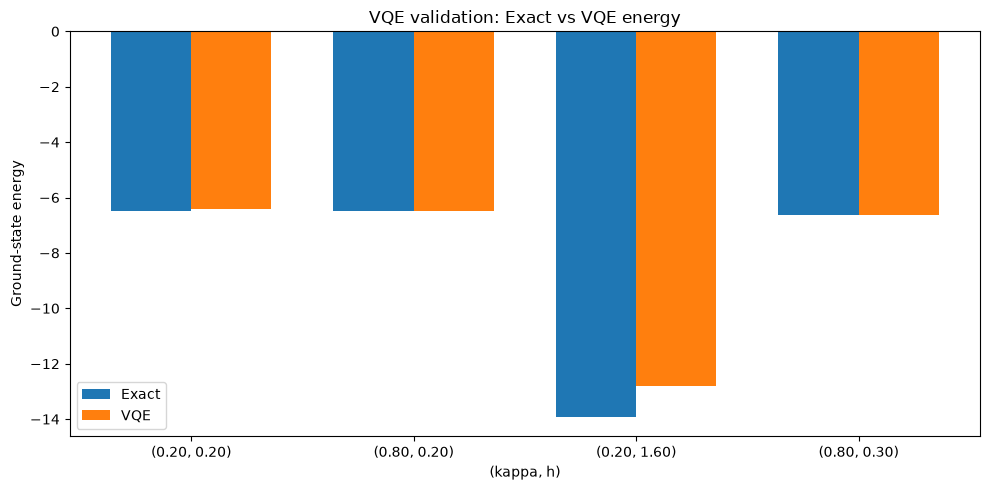

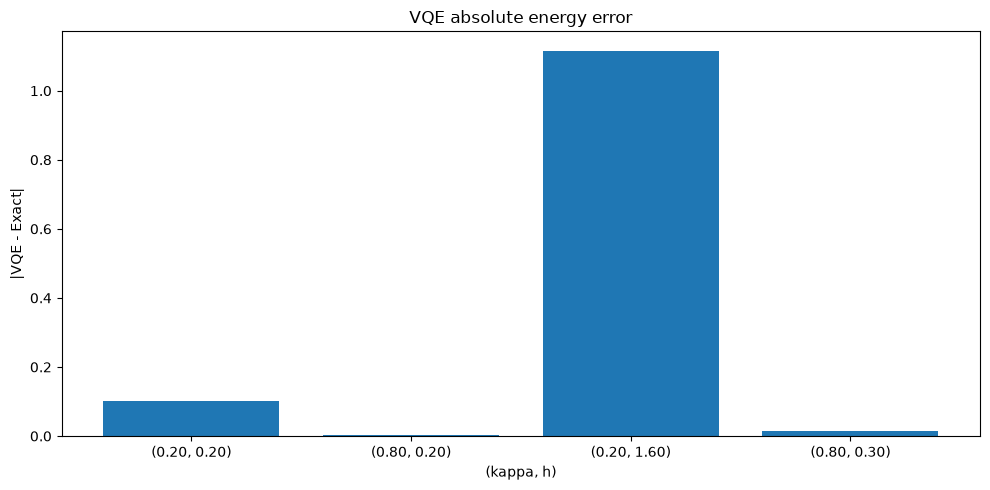

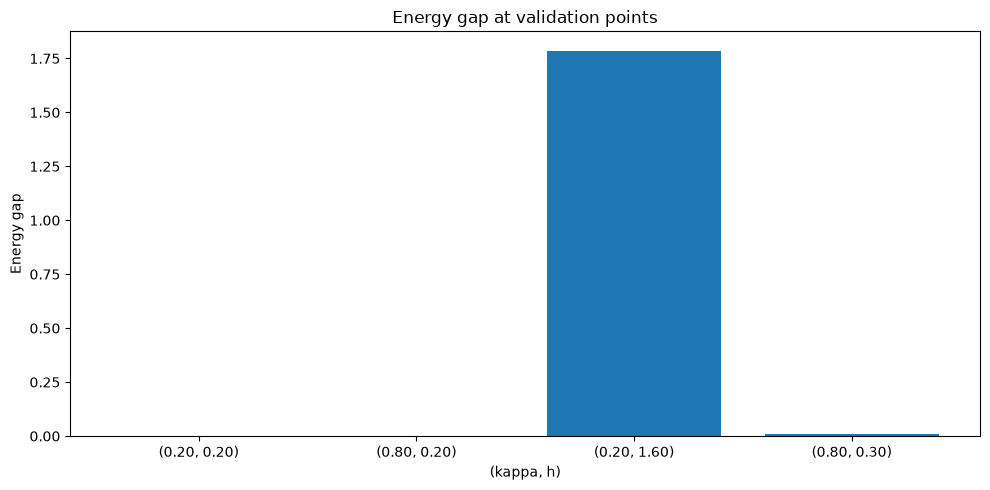

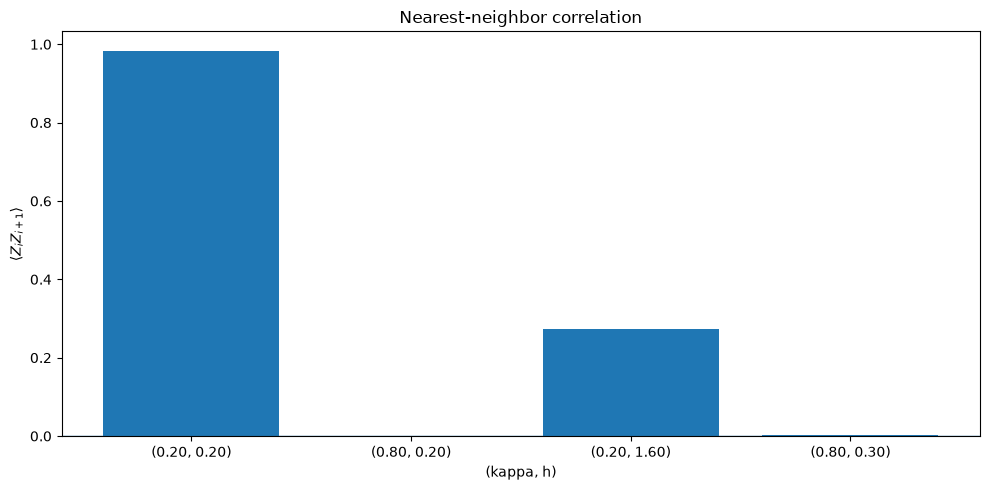

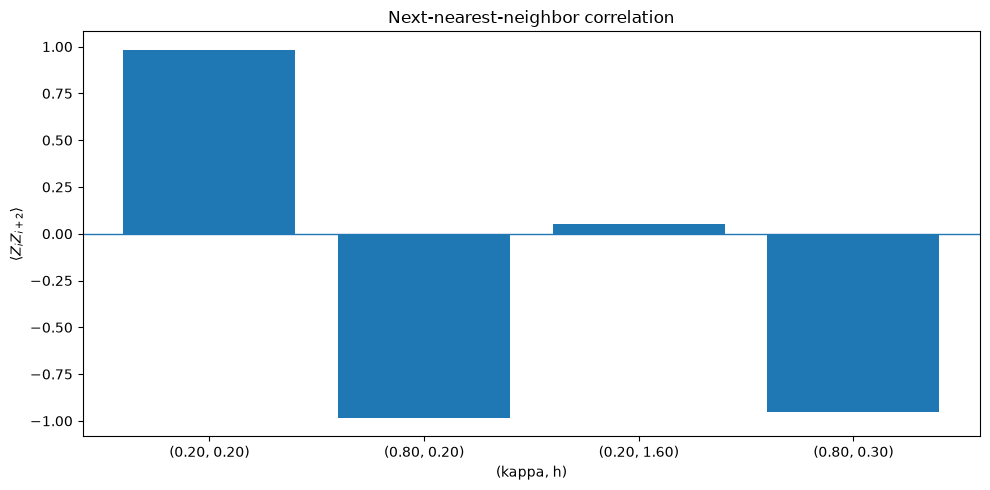

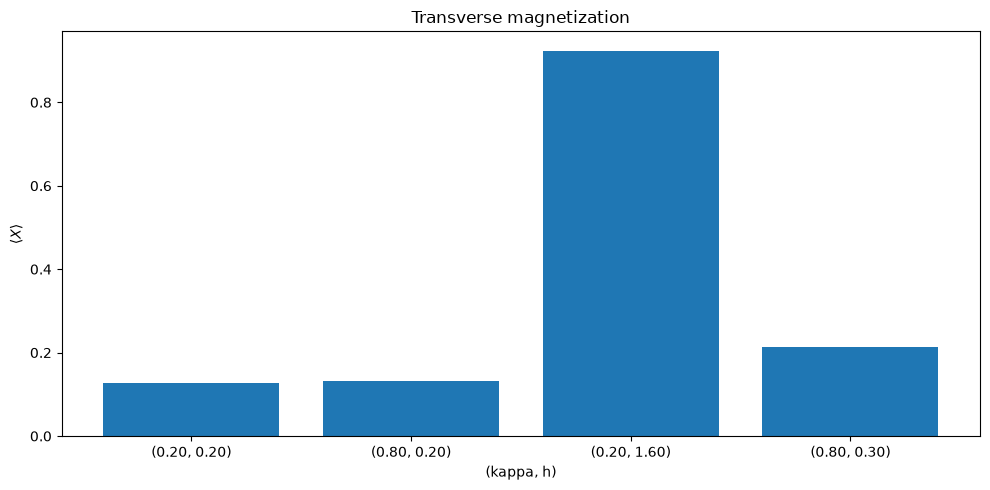

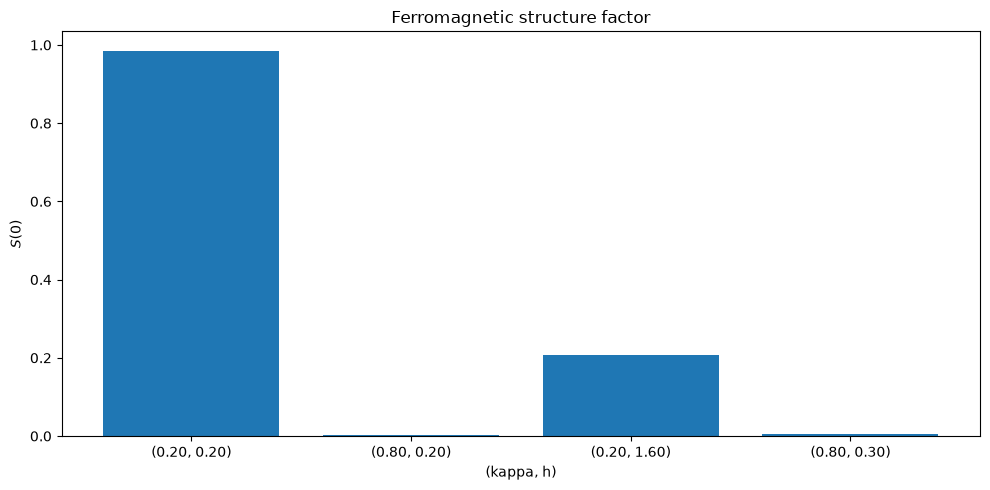

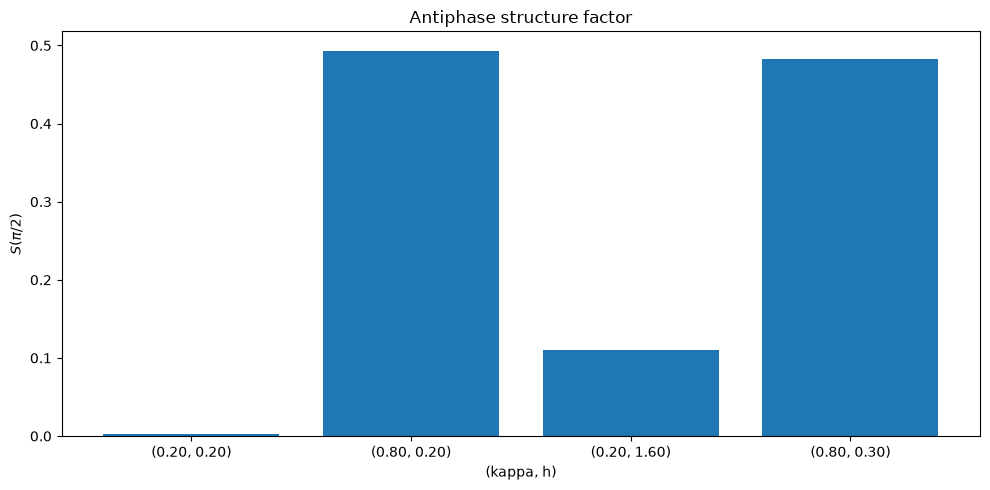



(kappa, h)  phase                   gap    ZZ_nn   ZZ_nnn        X   AP_str
───────────────────────────────────────────────────────────────
  (0.20, 0.20): 0                   0.0000   0.9839   0.9834   0.1272   0.0021
  (0.80, 0.20): 1                   0.0020   0.0003  -0.9826   0.1324   0.4934
  (0.20, 1.60): 2                   1.7863   0.2720   0.0542   0.9240   0.1108
  (0.80, 0.30): 1                   0.0107   0.0020  -0.9548   0.2143   0.4827


In [61]:

labels = [
    result["label"]
    for result in validation_results
]

x = np.arange(
    len(validation_results)
)

width = 0.36


# ============================================================
# 1. EXACT VS VQE ENERGY
# ============================================================

exact_energy = [
    result["exact_energy"]
    for result in validation_results
]

vqe_energy = [
    result["vqe_energy"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x - width / 2,
    exact_energy,
    width,
    label="Exact",
)

plt.bar(
    x + width / 2,
    vqe_energy,
    width,
    label="VQE",
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    "Ground-state energy"
)

plt.title(
    "VQE validation: Exact vs VQE energy"
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 2. VQE ABSOLUTE ERROR
# ============================================================

errors = [
    result["error"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    errors,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    "|VQE - Exact|"
)

plt.title(
    "VQE absolute energy error"
)

plt.tight_layout()

plt.show()


# ============================================================
# 3. ENERGY GAP
# ============================================================

gaps = [
    result["gap"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    gaps,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    "Energy gap"
)

plt.title(
    "Energy gap at validation points"
)

plt.tight_layout()

plt.show()


# ============================================================
# 4. NEAREST-NEIGHBOR CORRELATION
# ============================================================

zz_nn = [
    result["zz_nn"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    zz_nn,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    r"$\langle Z_i Z_{i+1}\rangle$"
)

plt.title(
    "Nearest-neighbor correlation"
)

plt.tight_layout()

plt.show()


# ============================================================
# 5. NEXT-NEAREST-NEIGHBOR CORRELATION
# ============================================================

zz_nnn = [
    result["zz_nnn"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    zz_nnn,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    r"$\langle Z_i Z_{i+2}\rangle$"
)

plt.title(
    "Next-nearest-neighbor correlation"
)

plt.tight_layout()

plt.show()


# ============================================================
# 6. TRANSVERSE MAGNETIZATION
# ============================================================

mx = [
    result["mx"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    mx,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    r"$\langle X\rangle$"
)

plt.title(
    "Transverse magnetization"
)

plt.tight_layout()

plt.show()


# ============================================================
# 7. FERROMAGNETIC STRUCTURE FACTOR S(0)
# ============================================================

s0 = [
    result["S0"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    s0,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    r"$S(0)$"
)

plt.title(
    "Ferromagnetic structure factor"
)

plt.tight_layout()

plt.show()


# ============================================================
# 8. ANTIPHASE STRUCTURE FACTOR S(pi/2)
# ============================================================

spi2 = [
    result["Spi2"]
    for result in validation_results
]

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x,
    spi2,
)

plt.xticks(
    x,
    labels,
)

plt.xlabel(
    "(kappa, h)"
)

plt.ylabel(
    r"$S(\pi/2)$"
)

plt.title(
    "Antiphase structure factor"
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. PHASE CLASSIFICATION
# ============================================================

print()
print()

print(
    "(kappa, h)  phase                   gap    "
    "ZZ_nn   ZZ_nnn        X   AP_str"
)

print(
    "───────────────────────────────────────────────────────────────"
)

for result in validation_results:

    print(
        f"  {result['label']:>12}: "
        f"{str(result['phase']):<18} "
        f"{result['gap']:>7.4f} "
        f"{result['zz_nn']:>8.4f} "
        f"{result['zz_nnn']:>8.4f} "
        f"{result['mx']:>8.4f} "
        f"{result['Spi2']:>8.4f}"
    )

In [64]:
vqe_params = np.empty(
    (
        len(hs_full),
        len(kappas_full),
    ),
    dtype=object,
)

vqe_energy = np.zeros(
    clean_shape
)

vqe_error = np.zeros(
    clean_shape
)

print()
print(
    f"Full VQE parameter scan: "
    f"N={N_MAIN}, "
    f"{RUN_GRID_RES}x{RUN_GRID_RES}"
)

for col, kappa in enumerate(
    kappas_full
):

    for row, h in enumerate(
        hs_full
    ):

        # Warm start along h, then across kappa.
        if row > 0:
            initial = vqe_params[
                row - 1,
                col,
            ]

        elif col > 0:
            initial = vqe_params[
                row,
                col - 1,
            ]

        else:
            initial = None

        params, energy = optimize_vqe_point(
            float(kappa),
            float(h),
            # initial_params=initial,
            seed=SEED
            + row
            + 100 * col,
        )

        exact_energy = (
            clean["energy"][row, col]
        )

        error = abs(
            energy
            - exact_energy
        )

        # If warm-started VQE misses significantly, retry from scratch.
        if error > 0.02 * N_MAIN:

            params, energy = optimize_vqe_point(
                float(kappa),
                float(h),
                # initial_params=None,
                # max_steps=120,
                seed=SEED + 10000
                + row
                + 100 * col,
            )

            error = abs(
                energy
                - exact_energy
            )

        vqe_params[
            row,
            col
        ] = params

        vqe_energy[
            row,
            col
        ] = energy

        vqe_error[
            row,
            col
        ] = error

    print(
        f"  kappa column "
        f"{col + 1}/{len(kappas_full)} complete"
    )

print("VQE scan complete.")


Full VQE parameter scan: N=8, 30x30
  time FM: 1.7284s | E = -8.000011
  time AP: 0.1852s | E = +0.000000
  time PM: 0.9862s | E = -4.000025
  time FM: 0.9752s | E = -8.000015
  time AP: 0.3786s | E = -8.009331
  time PM: 1.1380s | E = -0.551724
  time FM: 1.0541s | E = -8.000014
  time AP: 0.4731s | E = -8.037873
  time PM: 1.3234s | E = -1.103450
  time FM: 0.7218s | E = -8.000019
  time AP: 0.1036s | E = -8.085387
  time PM: 0.7060s | E = -1.655162
  time FM: 0.7918s | E = -8.000010
  time AP: 0.0749s | E = -8.151131
  time PM: 0.9865s | E = -2.206899
  time FM: 1.4762s | E = -8.000016
  time AP: 0.1459s | E = -8.237062
  time PM: 5.9726s | E = -2.758629
  time FM: 4.2558s | E = -8.000010
  time AP: 0.1488s | E = -8.341796
  time PM: 0.8437s | E = -3.310332
  time FM: 1.7034s | E = -8.000012
  time AP: 0.2813s | E = -8.460008
  time PM: 2.0765s | E = -3.862089
  time FM: 0.8063s | E = -8.000021
  time AP: 0.1132s | E = -8.608096
  time PM: 0.7529s | E = -4.413803
  time FM: 0.9585s

In [75]:
vqe_error

tensor([[1.14440918e-05, 1.17729450e-05, 2.06848671e-05, 4.80125691e-06,
         1.75278762e-05, 2.26251010e-05, 1.34172111e-05, 8.97769270e-06,
         1.69359404e-05, 1.15427478e-05, 1.09179267e-05, 2.31677088e-05,
         5.85358718e-06, 2.04875551e-05, 6.51129361e-06, 3.17836630e-05,
         1.71496950e-05, 2.44502364e-05, 1.97311928e-07, 4.71904360e-06,
         1.77416308e-05, 3.74399382e-05, 4.37868053e-05, 3.53517203e-05,
         2.40556125e-05, 4.04160598e-05, 3.28853229e-08, 8.28710096e-06,
         1.98791767e-05, 0.00000000e+00],
        [1.84566831e-04, 6.16311635e-05, 2.46286408e-05, 1.05946190e-02,
         1.10307691e-02, 1.14895350e-02, 1.19906068e-02, 1.25403973e-02,
         1.31457564e-02, 1.38155369e-02, 1.45594166e-02, 1.53922873e-02,
         1.63721577e-02, 1.75873377e-02, 1.11214051e-01, 9.27794857e-02,
         2.87834040e-04, 1.53570585e-04, 1.03828996e-04, 7.34736826e-05,
         5.24964329e-05, 3.63767315e-05, 3.17599431e-05, 2.45154225e-05,
         

In [70]:
np.save("/Users/soardr/QSITE-2026-QuantumCoalition/Scientific Track/vqe_params 30_30.npy", vqe_params)

### SAMPLE


## 2. Reading Phase Identity From Observables

We detect phases by measuring **order parameters** — quantities that take different values
in different phases.  The starter kit computes these from the exact ground-state vector:

| Observable | Symbol | Large positive value means… |
|---|---|---|
| Nearest-neighbor correlation | $\langle Z_i Z_{i+1} \rangle$ | Spins align → **ferromagnetic** |
| Next-nearest correlation | $\langle Z_i Z_{i+2} \rangle$ | Spins two sites apart are correlated |
| Transverse magnetization | $\langle X_i \rangle$ | Spins align with the field → **paramagnetic** |
| Antiphase string | $\langle Z_i Z_{i+1} \cdot Z_{i+2} Z_{i+3} \rangle$ | ↑↑↓↓ pattern → **antiphase** |

**Important caveat**: finite-size ground states often preserve global $\mathbb{Z}_2$
symmetry, so the raw magnetization $\langle Z_i \rangle$ stays near zero even in the
ferromagnetic phase.  Correlation-based observables are more reliable at small $N$.

Below we sample four representative $(\kappa, h)$ points — one per phase — and read the
observables. Use these to calibrate your intuition before scanning the full grid.

In [65]:
# Four representative points: (kappa, h, expected phase)
sample_points = [
    (0.20, 0.20, "ferromagnetic   "),
    (0.80, 0.20, "antiphase       "),
    (0.20, 1.60, "paramagnetic    "),
    (0.70, 0.90, "near-boundary   "),
]

header = (f"{'(kappa, h)':>14s}  {'phase':18s}  "
          f"{'gap':>7s}  {'ZZ_nn':>7s}  {'ZZ_nnn':>7s}  {'X':>7s}  {'AP_str':>7s}")
print(header)
print("─" * len(header))

for kappa, h, label in sample_points:
    res = exact_ground_state(n_qubits=DEMO_N, kappa=kappa, h=h, periodic=True)
    s = res["summary"]
    print(f"  ({kappa:.2f}, {h:.2f}):    {label}  "
          f"{res['energy_gap']:7.4f}  "
          f"{s['zz_nearest_mean']:7.4f}  "
          f"{s['zz_next_nearest_mean']:7.4f}  "
          f"{s['x_mean']:7.4f}  "
          f"{s['antiphase_string_mean']:7.4f}")

    (kappa, h)  phase                   gap    ZZ_nn   ZZ_nnn        X   AP_str
───────────────────────────────────────────────────────────────────────────────


KeyboardInterrupt: 

**Interpretation guide**:

- **Ferromagnetic** $(\kappa$ small, $h$ small): $\langle Z_i Z_{i+1} \rangle$ large and
  positive (neighboring spins aligned); $\langle X \rangle$ small.
- **Antiphase** $(\kappa > 0.5$, $h$ small): $\langle Z_i Z_{i+2} \rangle$ strongly
  *negative* (next-nearest anti-aligned); antiphase string $\approx 1$.
- **Paramagnetic** (large $h$): $\langle X \rangle$ large; both correlations suppressed.
- **Near a boundary**: small energy gap, observables change rapidly

The gap column also helps: a **phase transition** happens where the gap closes, so scanning the gap alongside order parameters can locate boundaries.

## 3. Clean Phase Survey

Now let's build a proper $(\kappa, h)$ grid and plot two observables as heatmaps.
We then overlay the **analytical phase boundaries** from the starter kit's `reference.py`.

The three reference lines are:
- **Ising transition** — ferro ↔ para (valid for $\kappa < 0.5$)
- **KT transition** — para ↔ antiphase (valid for $\kappa > 0.5$)
- **BKT transition** — lower boundary of the floating phase (valid for $\kappa > 0.5$)

At finite $N$ with periodic boundaries these are *qualitative* overlays; expect the numerical
boundaries to shift by a few grid squares compared to the thermodynamic-limit formulas.

This scan uses $N=6$ and a 20×20 grid — takes about 30 seconds on most laptops.
Your submission should use a finer grid (≥ 15×15) and $N \geq 8$.

In [80]:
GRID = 30  # increase for finer resolution
kappas = np.linspace(0.0, 1.0, GRID)
hs     = np.linspace(0.0, 2.0, GRID)

zz_nn  = np.zeros((GRID, GRID))
zz_nnn = np.zeros((GRID, GRID))
x_mag  = np.zeros((GRID, GRID))
total_eng  = np.zeros((GRID, GRID))
gap    = np.zeros((GRID, GRID))

print(f"Scanning {GRID}×{GRID} grid at N={DEMO_N} ...")
for row, h in enumerate(hs):
    for col, kappa in enumerate(kappas):
        # res = exact_ground_state(n_qubits=DEMO_N, kappa=float(kappa), h=float(h), periodic=True)
        # s = res["summary"]
        # zz_nn[row, col]  = s["zz_nearest_mean"]
        # zz_nnn[row, col] = s["zz_next_nearest_mean"]
        # x_mag[row, col]  = s["x_mean"]
        # total_eng[row, col]  = vqe_error[row][col]
        # gap[row, col]    = res["energy_gap"]
        gap[row, col]    = vqe_error[row][col]
    if (row + 1) % 5 == 0:
        print(f"  row {row+1}/{GRID} done")

print("Scan complete.")

Scanning 30×30 grid at N=12 ...
  row 5/30 done
  row 10/30 done
  row 15/30 done
  row 20/30 done
  row 25/30 done
  row 30/30 done
Scan complete.


In [81]:
vqe_energy.shape

(30, 30)

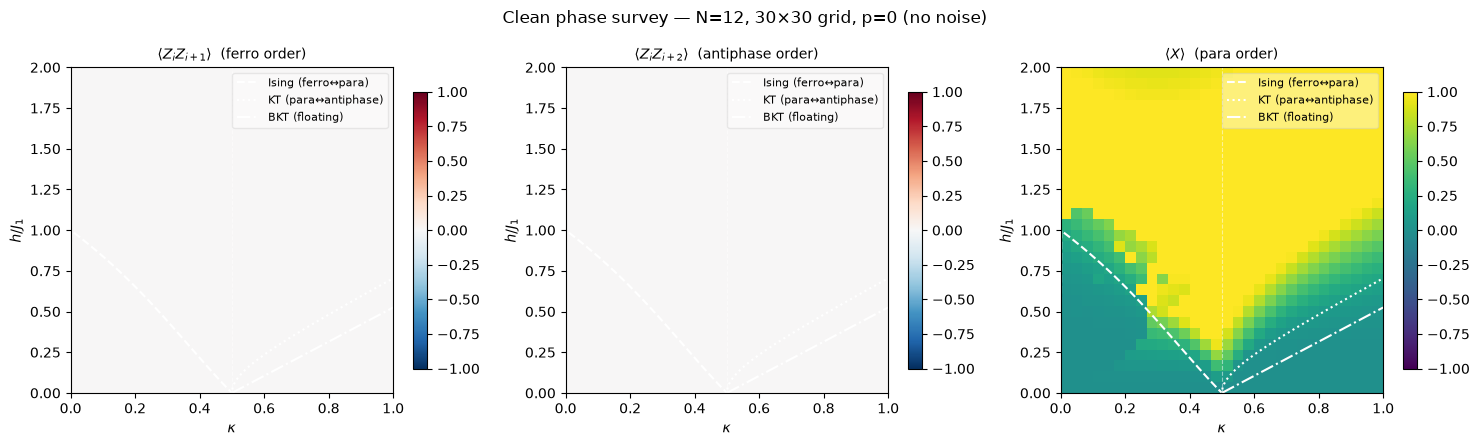

In [78]:
# Reference boundary curves
kappa_ref = np.linspace(0.0, 1.0, 500)
h_ising = ising_transition(kappa_ref)
h_kt    = kt_transition(kappa_ref)
h_bkt   = bkt_transition(kappa_ref)

def add_boundaries(ax):
    """Overlay analytical phase boundaries on a (kappa, h) heatmap axis."""
    ax.plot(kappa_ref, h_ising, "w--",  lw=1.5, label="Ising (ferro↔para)")
    ax.plot(kappa_ref, h_kt,    "w:",   lw=1.5, label="KT (para↔antiphase)")
    ax.plot(kappa_ref, h_bkt,   "w-.",  lw=1.5, label="BKT (floating)")
    ax.axvline(0.5, color="w", lw=0.8, alpha=0.5, linestyle="--")
    ax.legend(loc="upper right", fontsize=8, framealpha=0.4)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

observables = [
    (zz_nn,  r"$\langle Z_i Z_{i+1} \rangle$  (ferro order)",  "RdBu_r"),
    (zz_nnn, r"$\langle Z_i Z_{i+2} \rangle$  (antiphase order)", "RdBu_r"),
    # (x_mag,  r"$\langle X \rangle$  (para order)",              "viridis"),
    (total_eng,  r"$\langle X \rangle$  (para order)",              "viridis"),
]

for ax, (values, title, cmap) in zip(axes, observables):
    im = ax.imshow(
        values,
        origin="lower",
        aspect="auto",
        extent=[kappas.min(), kappas.max(), hs.min(), hs.max()],
        cmap=cmap,
        vmin=-1, vmax=1,
    )
    ax.set_xlabel(r"$\kappa$")
    ax.set_ylabel(r"$h / J_1$")
    ax.set_title(title, fontsize=10)
    add_boundaries(ax)
    fig.colorbar(im, ax=ax, shrink=0.85)

fig.suptitle(f"Clean phase survey — N={DEMO_N}, {GRID}×{GRID} grid, p=0 (no noise)", fontsize=12)
fig.tight_layout()
plt.show()

In [35]:
# Animate one observable along line cuts at fixed h, sweeping kappa
anim = animate_linecut(
    kappas, hs, zz_nn,
    ylabel=r"$\langle Z_i Z_{i+1} \rangle$",
    title="Nearest-neighbor correlation at",
)
display(anim)

## 4. The Noise Model

Real quantum hardware introduces errors.  The challenge inherits the **depolarizing noise**
model from the PennyLane Noisy Heisenberg challenge:

> After every CNOT gate, apply `qml.DepolarizingChannel(p)` on the **target** qubit.
> This replaces the target state with a completely random state with probability $p$.

- $p = 0$: perfect gates (clean simulation)
- $p = 0.01$: 1% error per CNOT — mild noise
- $p = 0.05$: 5% error per CNOT — significant noise

Noise requires a **density-matrix simulator** because errors turn pure states into mixed
states.  Use `qml.device("default.mixed", wires=n)` instead of `"default.qubit"`.

The starter kit's `noisy_entangling_layer` and `simple_noisy_energy` demonstrate this
convention.  Your submission should extend it to compute noisy order parameters at each
$(\kappa, h)$ grid point.

In [36]:
# Show the noisy circuit structure using qml.draw
dev_mixed = qml.device("default.mixed", wires=4)

@qml.qnode(dev_mixed)
def demo_noisy_circuit(theta, p):
    noisy_entangling_layer(n_qubits=4, theta=theta, p=p)
    return qml.expval(qml.Z(0))

print("Noisy circuit structure (N=4, one layer):")
print(qml.draw(demo_noisy_circuit)(theta=0.5, p=0.02))

Noisy circuit structure (N=4, one layer):
0: ──RY(0.50)─╭●──────────────────────────────────────────────────────────── ···
1: ──RY(0.50)─╰X──DepolarizingChannel(0.02)─╭●────────────────────────────── ···
2: ──RY(0.50)───────────────────────────────╰X──DepolarizingChannel(0.02)─╭● ···
3: ──RY(0.50)─────────────────────────────────────────────────────────────╰X ···

0: ··· ────────────────────────────╭X──DepolarizingChannel(0.02)─┤  <Z>
1: ··· ────────────────────────────│─────────────────────────────┤     
2: ··· ────────────────────────────│─────────────────────────────┤     
3: ··· ──DepolarizingChannel(0.02)─╰●────────────────────────────┤     


In [37]:
# Compare clean vs noisy energy at several (kappa, h) points
noise_levels = [0.0, 0.01, 0.03, 0.05]

test_points = [
    (0.2, 0.2, "ferromagnetic"),
    (0.8, 0.2, "antiphase    "),
    (0.2, 1.6, "paramagnetic "),
]

print(f"{'phase':13s}  {'(κ, h)':>10s}  " +
      "  ".join(f"p={p:.2f}" for p in noise_levels))
print("─" * 65)

for kappa, h, label in test_points:
    energies = [
        simple_noisy_energy(n_qubits=4, kappa=kappa, h=h, theta=0.4, p=p, layers=2)
        for p in noise_levels
    ]
    row = "  ".join(f"{e:+7.4f}" for e in energies)
    print(f"{label}  ({kappa:.1f}, {h:.1f})  {row}")

phase              (κ, h)  p=0.00  p=0.01  p=0.03  p=0.05
─────────────────────────────────────────────────────────────────
ferromagnetic  (0.2, 0.2)  -2.0987  -1.9635  -1.7146  -1.4924
antiphase      (0.8, 0.2)  -0.1418  -0.0849  +0.0138  +0.0942
paramagnetic   (0.2, 1.6)  -3.4967  -3.3061  -2.9514  -2.6296


**What to notice**:

- In **ordered phases** (ferromagnetic, antiphase), increasing $p$ pushes the energy
  *up* (toward a more disordered, higher-energy-looking state).  Noise destroys the
  quantum correlations that stabilize the ordered phase.
- In the **paramagnetic** phase, the effect is smaller because the ground state is
  already partly aligned with the field (less entangled, more noise-resistant).
- At large $p$, all phases start to look similar — noise homogenizes the phase portrait.

Your challenge: **quantify** this effect.  Which phase boundary shifts the most under
$p = 0.05$?  Which phase shrinks the fastest?  Which observable is the most sensitive?

## 5. Noise Comparison at Fixed $\kappa$

Before running the full noisy grid (which takes longer), let's do a quick 1D cut at a
fixed $\kappa$ to see how the observable profile changes with noise.

This uses `simple_noisy_energy` which runs a small fixed ansatz — not a ground-state
solver.  For your submission you'll want to replace this with VQE (optimized parameters)
or exact diagonalization extended with a noisy measurement channel.  But this is enough
to see the qualitative effect.

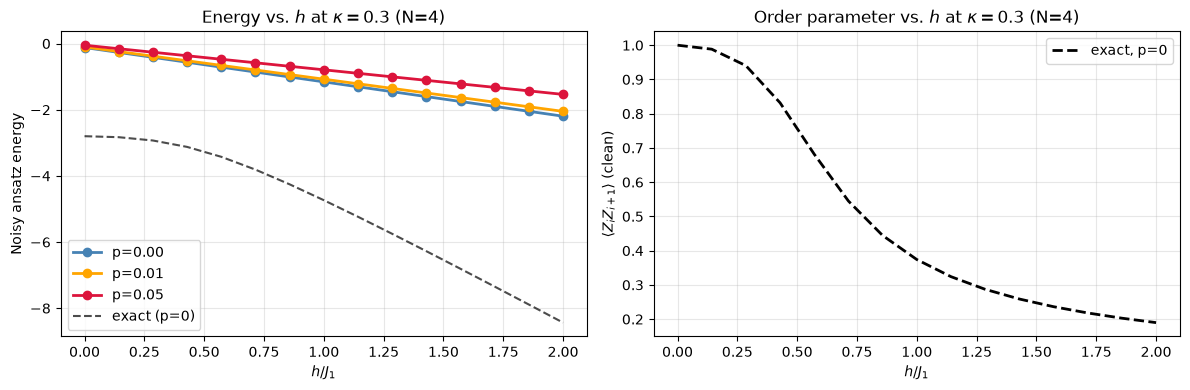

The clean ZZ correlation drops sharply around the ferro→para transition.
Your task: show this drop shifting / blurring as noise increases.


In [9]:
# 1D scan at kappa=0.3 (ferro→para transition region), sweeping h
kappa_cut = 0.3
hs_cut = np.linspace(0.0, 2.0, 15)
n_cut = 4  # small N for speed; use larger N in your submission

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for p, color in zip([0.0, 0.01, 0.05], ["steelblue", "orange", "crimson"]):
    energies = [
        simple_noisy_energy(n_qubits=n_cut, kappa=kappa_cut, h=float(h),
                            theta=0.5, p=p, layers=3)
        for h in hs_cut
    ]
    axes[0].plot(hs_cut, energies, marker="o", color=color, label=f"p={p:.2f}", lw=2)

axes[0].set_xlabel(r"$h / J_1$")
axes[0].set_ylabel("Noisy ansatz energy")
axes[0].set_title(fr"Energy vs. $h$ at $\kappa={kappa_cut}$ (N={n_cut})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Show clean exact-diag ground state for comparison
exact_energies = [
    exact_ground_state(n_qubits=n_cut, kappa=kappa_cut, h=float(h), periodic=True)["ground_energy"]
    for h in hs_cut
]
axes[0].plot(hs_cut, exact_energies, "k--", lw=1.5, label="exact (p=0)", alpha=0.7)
axes[0].legend()

# Also show what the nearest-neighbor ZZ correlation looks like
for p, color in zip([0.0, 0.01, 0.05], ["steelblue", "orange", "crimson"]):
    # approximate: use exact ZZ at p=0 and scale heuristically
    # (teams should replace with noisy expectation value measurement)
    pass

zz_clean = [
    exact_ground_state(n_qubits=n_cut, kappa=kappa_cut, h=float(h), periodic=True)
    ["summary"]["zz_nearest_mean"]
    for h in hs_cut
]
axes[1].plot(hs_cut, zz_clean, "k--", lw=2, label="exact, p=0")
axes[1].set_xlabel(r"$h / J_1$")
axes[1].set_ylabel(r"$\langle Z_i Z_{i+1} \rangle$ (clean)")
axes[1].set_title(fr"Order parameter vs. $h$ at $\kappa={kappa_cut}$ (N={n_cut})")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

print("The clean ZZ correlation drops sharply around the ferro→para transition.")
print("Your task: show this drop shifting / blurring as noise increases.")

## 6. Your Phase Diagrams

Build your submission here.  Required deliverables:

| Deliverable | Format |
|---|---|
| Clean phase diagram ($p = 0$) | Image (PNG/PDF) — you may adapt Section 3 above |
| Noisy phase diagram ($p = 0.01$) | Same format |
| Noisy phase diagram ($p = 0.05$) | Same format |
| Analysis writeup | Markdown or PDF, 2–3 pages |

**Checklist for a strong submission**:
- Grid resolution ≥ 15×15 (more is better)
- System size $N \geq 8$ (N=6 is fine for demos but not for submission)
- Phase boundaries overlaid using `ising_transition`, `kt_transition`, `bkt_transition`
- Quantitative analysis: "the ferro→para boundary at $\kappa=0.3$ shifts from $h=X$ to $h=Y$"
- Discussion of *which* phases are most/least robust to noise and *why*

**Approach options** (choose one or compare multiple):
- **Order parameters via exact diag** — fastest to implement; use `exact_ground_state` + a
  noisy measurement simulation
- **VQE** — optimize ansatz parameters at each grid point; use `qml.GradientDescentOptimizer`
- **QCNN or autoencoder** — train a classifier; see the PennyLane ANNNI demo
- **Fidelity susceptibility** — compute overlap between neighboring ground states

In [10]:
# ── Your implementation goes here ─────────────────────────────────────────────
# Suggested structure:

# STEP 1: Define your scan parameters
GRID_N = 8          # system size (increase for better physics)
GRID_RES = 15       # grid resolution
kappas_full = np.linspace(0.0, 1.0, GRID_RES)
hs_full     = np.linspace(0.0, 2.0, GRID_RES)
noise_ps    = [0.0, 0.01, 0.05]

# STEP 2: Choose your observable and compute it at each (kappa, h, p)
# Example skeleton for order-parameter approach:
#
# results = {}  # (p_value) -> 2D array of shape (GRID_RES, GRID_RES)
# for p in noise_ps:
#     grid = np.zeros((GRID_RES, GRID_RES))
#     for row, h in enumerate(hs_full):
#         for col, kappa in enumerate(kappas_full):
#             # Replace with your noisy measurement
#             res = exact_ground_state(n_qubits=GRID_N, kappa=float(kappa), h=float(h))
#             grid[row, col] = res["summary"]["zz_nearest_mean"]
#     results[p] = grid

# STEP 3: Plot and save
# for p, grid in results.items():
#     fig, ax = plot_observable_heatmap(grid, kappas_full, hs_full,
#                                       title=f"ZZ correlation, p={p}")
#     add_boundaries(ax)  # defined in Section 3
#     fig.savefig(f"phase_diagram_p{p:.2f}.pdf", bbox_inches="tight")
#     plt.show()

print("Replace this cell with your scan loop and analysis.")

Replace this cell with your scan loop and analysis.


## References

- PennyLane demo — [ANNNI Phase Detection](https://pennylane.ai/qml/demos/tutorial_annni) (primary reference — QCNN and autoencoder approaches)
- PennyLane challenge — [A Noisy Heisenberg Model](https://pennylane.ai/challenges/heisenberg_model) (noise convention used in this challenge)
- PennyLane demo — [Seeing Quantum Phase Transitions](https://pennylane.ai/qml/demos/tutorial_quantum_phase_transitions) (VQE + order parameter approach)
- PennyLane demo — [How to Build Spin Hamiltonians](https://pennylane.ai/qml/demos/tutorial_how_to_build_spin_hamiltonians)
- Kiss / Monaco et al., *Phys. Rev. B* 107, L081105 (2023) — paper behind the ANNNI demo
- Cea et al., arXiv:2402.11022 (2024) — extended study including floating phase
- [CERN reference implementation](https://github.com/CERN-IT-INNOVATION/Quantum-Phase-Detection-ANNNI) — full notebooks with pre-computed data